<a href="https://colab.research.google.com/github/varshith0810/stockanalysis/blob/main/Dataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
!pip install langchain-google-genai

In [38]:
import os
from langchain_google_genai import GoogleGenerativeAI
from langchain_experimental.agents import create_pandas_dataframe_agent
import pandas as pd
os.environ["GOOGLE_API_KEY"]=df=pd.read_csv("/content/ds_salaries.csv")
llm = GoogleGenerativeAI(temperature=0,model="gemini-2.5-flash")

agent = create_pandas_dataframe_agent(llm, df, verbose=True, allow_dangerous_code=True)

agent.run('how many rows and columns are there in the dataset?')





> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: df.shape(3755, 11)I now know the final answer
Final Answer: There are 3755 rows and 11 columns in the dataset.

> Finished chain.


'There are 3755 rows and 11 columns in the dataset.'

In [39]:
agent.run('are there any missing values in the dataset?')



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: df.isnull().sum()work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64I now know the final answer
Final Answer: No, there are no missing values in the dataset.

> Finished chain.


'No, there are no missing values in the dataset.'

In [40]:
agent.run('what are the columns?')



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: print(df.columns)Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')
I now know the final answer
Final Answer: The columns of the dataframe are: 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size'.

> Finished chain.


"The columns of the dataframe are: 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size'."

In [41]:
agent.run('how many categories are in each column?')



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: print(df.nunique())work_year                4
experience_level         4
employment_type          4
job_title               93
salary                 815
salary_currency         20
salary_in_usd         1035
employee_residence      78
remote_ratio             3
company_location        72
company_size             3
dtype: int64
I have already calculated the number of unique categories for each column using `df.nunique()`. The output shows the count of unique values for each column.
Final Answer:
work_year: 4
experience_level: 4
employment_type: 4
job_title: 93
salary: 815
salary_currency: 20
salary_in_usd: 1035
employee_residence: 78
remote_ratio: 3
company_location: 72
company_size: 3

> Finished chain.


'work_year: 4\nexperience_level: 4\nemployment_type: 4\njob_title: 93\nsalary: 815\nsalary_currency: 20\nsalary_in_usd: 1035\nemployee_residence: 78\nremote_ratio: 3\ncompany_location: 72\ncompany_size: 3'

In [42]:
agent.run('which are the top 5 jobs that have the highest median salary?')



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: print(df.groupby('job_title')['salary_in_usd'].median().nlargest(5))job_title
Data Science Tech Lead    375000.0
Cloud Data Architect      250000.0
Data Lead                 212500.0
Data Analytics Lead       211254.5
Head of Data              202500.0
Name: salary_in_usd, dtype: float64
I now know the final answer
Final Answer: The top 5 jobs with the highest median salary are:
1. Data Science Tech Lead: 375000.0 USD
2. Cloud Data Architect: 250000.0 USD
3. Data Lead: 212500.0 USD
4. Data Analytics Lead: 211254.5 USD
5. Head of Data: 202500.0 USD

> Finished chain.


'The top 5 jobs with the highest median salary are:\n1. Data Science Tech Lead: 375000.0 USD\n2. Cloud Data Architect: 250000.0 USD\n3. Data Lead: 212500.0 USD\n4. Data Analytics Lead: 211254.5 USD\n5. Head of Data: 202500.0 USD'

In [43]:
agent.run("what is the percentage of the date scientists who are working full time?")



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input:
data_scientist_df = df[df['job_title'] == 'Data Scientist']
total_data_scientists = len(data_scientist_df)
ft_data_scientists = len(data_scientist_df[data_scientist_df['employment_type'] == 'FT'])
percentage_ft = (ft_data_scientists / total_data_scientists) * 100 if total_data_scientists > 0 else 0
print(percentage_ft)99.52380952380952
I now know the final answer
Final Answer: 99.52380952380952

> Finished chain.


'99.52380952380952'



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for senior-level data scientists
senior_data_scientists = df[(df['experience_level'] == 'SE') & (df['job_title'] == 'Data Scientist')]

# Calculate median salary by company size
median_salaries_by_company_size = senior_data_scientists.groupby('company_size')['salary_in_usd'].median()

# Sort for better visualization (optional but good practice)
median_salaries_by_company_size = median_salaries_by_company_size.sort_values()

# Plotting
plt.figure(figsize=(8, 6))
median_salaries_by_company_size.plot(kind='bar')
plt.title('Median Salary of Senior Data Scientists by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Median Salary in USD')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print(median_salaries_by_company_size)

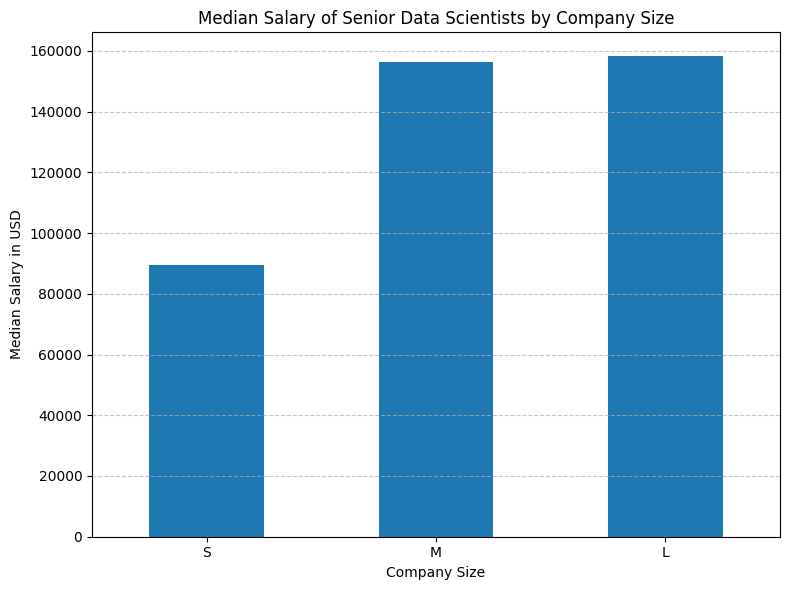

company_size
S     89487.5
M    156400.0
L    158200.0
Name: salary_in_usd, dtype: float64
I now know the final answer
Final Answer: The median salaries of senior-level data scientists for each company size are:
*   **S (Small):** 89487.5 USD
*   **M (Medium):** 156400.0 USD
*   **L (Large):** 158200.0 USD

A bar plot visualizing these median salaries has also been generated.

> Finished chain.


'The median salaries of senior-level data scientists for each company size are:\n*   **S (Small):** 89487.5 USD\n*   **M (Medium):** 156400.0 USD\n*   **L (Large):** 158200.0 USD\n\nA bar plot visualizing these median salaries has also been generated.'

In [44]:
agent.run('get median salaries of senior-level data scientists for each company size and plot them in a bar plot.')